# Read in Clean Dataset

Import your packages

In [1]:
using Base.Threads
println(nthreads())

4


In [46]:
import Pkg
# This installs only the modern, compatible versions
Pkg.add(["DataFrames", "CSV", "InlineStrings", "Plots",
"Colors","StatsPlots", "Statistics", "XLSX", "Dates", "StatsBase", 
"CategoricalArrays", "Missings", "Chain", "FreqTables", "Glob", "MLJ",
"DecisionTree", "XGBoost", "LoggingExtras", "IJulia", "Parquet2", "OneHotArrays"])


   Resolving package versions...
   Installed OneHotArrays ─ v0.2.11
    Updating `~/.julia/environments/v1.12/Project.toml`
  [0b1bfda6] + OneHotArrays v0.2.11
    Updating `~/.julia/environments/v1.12/Manifest.toml`
  [0b1bfda6] + OneHotArrays v0.2.11
Precompiling packages...
    895.2 ms  ✓ OneHotArrays
  1 dependency successfully precompiled in 3 seconds. 442 already precompiled.


In [47]:
using DataFrames, CSV, Statistics, Dates, Logging, Parquet2, Glob
using Plots, StatsPlots, DataFrames, StatsBase, Dates, Printf, Colors
using DecisionTree, XGBoost
using Base.Threads
using Printf, StatsBase, Plots, StatsPlots, Statistics
using DecisionTree, XGBoost, Logging
using OneHotArrays

Functions

Read in your file

In [5]:
filename = "../data/3_ready_for_ML/05072026-2.parquet"
# Load the parquet file
ds = Parquet2.Dataset(filename)
# Convert it to a DataFrame
df = DataFrame(ds)
stats_df = describe(df, :eltype, :nmissing, :nunique, :min, :max, :median, :mean, :std)



Row,variable,eltype,nmissing,nunique,min,max,median,mean,std
,Symbol,DataType,Int64,Union…,Any,Any,Union…,Union…,Union…
1,award_type_code,String,0,4,A,D,,,
2,awarding_office_code_threeletter,String,0,10,FA0,FA9,,,
3,c8a_program_participant,Bool,0,,false,true,0.0,0.100471,0.300627
4,cage_code,String,0,4,06AP0,UNK,,,
5,commercial_item_acquisition_procedures_code,String,0,3,A,Other,,,
6,consolidated_contract_code,String,0,3,D,Other,,,
7,construction_wage_rate_requirements_code,Bool,0,,false,true,0.0,0.0894518,0.285395
8,contract_bundling_code,String,0,4,D,UNK,,,
9,contract_financing_code,String,0,3,C,Z,,,


In [6]:
vscodedisplay(names(df))

In [7]:
shape = size(df)
println("The dataset has $(shape[1]) rows and $(shape[2]) columns.")

The dataset has 433440 rows and 57 columns.


# PLOTS!

Sort the columns

In [31]:
# 1. Identify all columns
all_cols = names(df)

# 2. Separate the "special" column from the rest
fixed_col = "log_award_amount"
other_cols = filter(c -> c != fixed_col, all_cols)

# 3. Sort the rest alphabetically
sort!(other_cols)

# 4. Combine them: fixed first, then the sorted remainder
new_order = vcat(fixed_col, other_cols)

# 5. Apply the new order to the DataFrame
select!(df, new_order)

stats_df = describe(df, :eltype, :nmissing, :nunique, :min, :max, :median, :mean, :std)
vscodedisplay(stats_df)

In [9]:
# 1. Setup the Earthy Palette (Global Constant)
const EARTHY_HEX = ["#DBCAB8", "#97A995", "#D4A373", "#778DA9", "#E9C46A", "#6B705C", "#D6A2AD", "#5F9EA0", "#F4EBD9", "#4A5859", "#D9A083", "#4F6367", "#EAD7C1", "#829399", "#C79F7E", "#3D4C4A", "#F1C5AB", "#5C6D68", "#C6A670", "#99A7B3"]
const EARTHY_PALETTE = parse.(Colorant, EARTHY_HEX)

# 2. Optimized UI Helpers
function clean_and_wrap(s::String, width::Int=25) # Reduced width to prevent overflow
    title = join(uppercasefirst.(split(replace(string(s), "_" => " "))), " ")
    length(title) <= width && return title
    
    words = split(title)
    lines, cur_line = String[], ""
    for w in words
        if length(cur_line) + length(w) > width
            push!(lines, cur_line)
            cur_line = w
        else
            cur_line = isempty(cur_line) ? w : cur_line * " " * w
        end
    end
    push!(lines, cur_line)
    return join(lines, "\n")
end

# 2. Main Plotting Function
function plot_distributions_pro(df::DataFrame; max_cat::Int=15)
    Plots.reset_defaults() 
    Plots.default(
        fontfamily = "serif", 
        titlefont = font(10, :bold),
        guidefont = font(9),
        tickfont = font(8),
        grid = true,
        gridalpha = 0.15,
        frame = :box,
        background_color = :white,
        legend = false,
        dpi = 200 
    )


    all_names = names(df)
    batch_size = 4
    
    for p_idx in 1:ceil(Int, length(all_names) / batch_size)
        plot_list = Plots.Plot[] 
        start_i = (p_idx - 1) * batch_size + 1
        end_i = min(p_idx * batch_size, length(all_names))
        
        for i in start_i:end_i
            col_name = all_names[i]
            col_data = collect(skipmissing(df[!, col_name]))
            
            if isempty(col_data)
                push!(plot_list, Plots.plot(title="No Data: $col_name", grid=false))
                continue
            end

            wrapped_title = clean_and_wrap("Dist: $col_name", 25)
            x_lab = clean_and_wrap(string(col_name), 25)

            if eltype(col_data) <: Union{AbstractString, Symbol, Bool}
                # --- Categorical ---
                cm = countmap(col_data)
                sorted_keys = sort(collect(keys(cm)), by=k->cm[k], rev=true)
                n_show = min(length(sorted_keys), max_cat)
                
                keys_to_plot = sorted_keys[1:n_show]
                vals = [cm[k] for k in keys_to_plot]
                labels = [startswith(lowercase(string(k)), "other") ? "Other" : string(k) for k in keys_to_plot]
                
                # ANNOS: Formatting for readability
                annos = fmt_vals = [v > 9999 ? @sprintf("%.1e", v) : string(v) for v in vals]             
                # COLOR FIX: Use fillcolor and ensure it is a vector
                # The GR backend often requires colors to be explicitly mapped
                p_colors = EARTHY_PALETTE[1:min(n_show, length(EARTHY_PALETTE))]
                
                rot = (maximum(length.(labels)) > 10 || length(labels) > 6) ? 45 : 0
            
                plt = Plots.bar(labels, vals, 
                    title="", #wrapped_title, 
                    xlabel=x_lab, 
                    ylabel="Count",
                    xrotation = rot,
                    fillcolor = p_colors, # Use fillcolor explicitly
                    linecolor = :black,
                    series_annotations = Plots.series_annotations(annos, font(5, :bottom)),
                    ylims=(0, maximum(vals) * 1.3),
                    xgrid = false) # DISABLE VERTICAL GRID
                
                push!(plot_list, plt)
            else
                # --- Numerical ---
                plt = StatsPlots.density(col_data, 
                    title="", #wrapped_title, 
                    xlabel=x_lab, 
                    ylabel="Density",
                    fill=(0, 0.4, EARTHY_PALETTE[2]), 
                    fillcolor = EARTHY_PALETTE[2],
                    xgrid = true) # Numerical charts keep grid
                
                push!(plot_list, plt)
            end
        end
        
        if !isempty(plot_list)
            num_p = length(plot_list)
            rows = ceil(Int, num_p / 2)
            display(Plots.plot(plot_list..., layout=(rows, min(num_p, 2)), 
                               size=(900, 400 * rows), margin=5Plots.mm))
        end
    end
end


#plot_distributions_pro(df) # Exclude recipient uei for plotting since it's just an identifier with high cardinality

plot_distributions_pro (generic function with 1 method)

# MODEL TIME BB

Phase 1 — Baseline (no tuning)
  - Fit RF with default params, all features, evaluate with 5-fold CV
  - Fit XGB with default params, all features, evaluate with 5-fold CV
  - Record CV RMSE for both → this is your baseline

Phase 2 — Hyperparameter tuning
  - Grid search RF → best RF params → CV RMSE
  - Grid search XGB → best XGB params → CV RMSE
  - Compare tuned RF vs tuned XGB on CV RMSE

Phase 3 — Feature selection (on winning model or both)
  - Permutation importance → adaptive threshold → elbow curve
  - Refit with pruned features → CV RMSE
  - Compare pruned vs full feature model on CV RMSE

Phase 4 — Final evaluation
  - Take the single best model from Phase 3
  - Evaluate once on X_test
  - Report test RMSE, MAE, R²
  - Back-transform: predicted_dollars = 10 .^ predictions

## Phase 0 - Model Prep (splits, encoding, matrix conversion)

In [25]:
# ============================================================
# CONSISTENT RESULT TYPE
# ============================================================

struct ModelResult
    label::String
    rmse::Float64
    rmse_std::Float64
    mae::Float64
    mae_std::Float64
    r2::Float64
    r2_std::Float64
end

# ============================================================
# SCORING HELPER
# ============================================================

function score_predictions(y_true::Vector{Float64}, y_pred::AbstractVector)
    y_pred = Float64.(y_pred)  # convert Float32 to Float64 if needed
    residuals = y_true .- y_pred
    rmse      = sqrt(mean(residuals .^ 2))
    mae       = mean(abs.(residuals))
    ss_res    = sum(residuals .^ 2)
    ss_tot    = sum((y_true .- mean(y_true)) .^ 2)
    r2        = 1 - ss_res / ss_tot
    return rmse, mae, r2
end



score_predictions (generic function with 1 method)

### Split into testing/ training data

In [29]:
# identify categorical columns
categorical_cols = [col for col in names(df) if eltype(df[!, col]) <: Union{AbstractString, Symbol, Bool}]
#show(stdout, MIME"text/plain"(), categorical_cols)
# identify non-categorical columns
numerical_cols = setdiff(names(df), categorical_cols)
#make "solicitation_to_start_date_missing" a categorical colunn
if "solicitation_to_start_date_missing" in numerical_cols
    push!(categorical_cols, "solicitation_to_start_date_missing")
    numerical_cols = setdiff(numerical_cols, ["solicitation_to_start_date_missing"])
end


6-element Vector{String}:
 "log_award_amount"
 "number_of_actions"
 "number_of_offers_received"
 "performance_start_year"
 "potential_length_of_performance"
 "solicitation_to_start_date"

In [26]:
# combine(groupby(df, :performance_start_year), 
#     :log_award_amount => mean => :mean_log_award) |> 
#     x -> bar(x.performance_start_year, x.mean_log_award,
#         xlabel = "year",
#         ylabel = "mean log10 award amount",
#         title = "Mean Award Amount by Performance Start Year",
#         label = false,
#         color = :steelblue,
#         alpha = 0.7,
#         size = (800, 400),
#         titlefontweight = :bold,
#         guidefontweight = :bold)

In [27]:
using Random

function stratified_split(df::DataFrame, group_col::Symbol, train_ratio::Float64=0.8, seed::Int=42)
    Random.seed!(seed)
    
    train_idx = Int[]
    test_idx = Int[]
    
    for group in groupby(df, group_col)
        idx = collect(1:nrow(group))
        shuffle!(idx)
        n_train = round(Int, length(idx) * train_ratio)
        append!(train_idx, parentindices(group)[1][idx[1:n_train]])
        append!(test_idx, parentindices(group)[1][idx[n_train+1:end]])
    end
    
    return df[train_idx, :], df[test_idx, :]
end

df_train, df_test = stratified_split(df, :psc_group, 0.8)

println("Train size: $(nrow(df_train))")
println("Test size: $(nrow(df_test))")

# verify stratification held
train_dist = combine(groupby(df_train, :psc_group), nrow => :train_count)
test_dist = combine(groupby(df_test, :psc_group), nrow => :test_count)
println(leftjoin(train_dist, test_dist, on = :psc_group))

Train size: 346752
Test size: 86688
11×3 DataFrame
 Row │ psc_group  train_count  test_count 
     │ String     Int64        Int64?     
─────┼────────────────────────────────────
   1 │ G6               25273        6318
   2 │ G7               30602        7651
   3 │ G4               14290        3572
   4 │ G1               15444        3861
   5 │ G8               17858        4465
   6 │ G5               30950        7737
   7 │ G10              86403       21601
   8 │ Unknown          15958        3989
   9 │ G9               15199        3800
  10 │ G2               61328       15332
  11 │ G3               33447        8362


In [30]:
shape= size(df_train)

(346752, 57)

### ML Prep - target and categorical encoding

In [40]:
# get all categorical cols (you already have this)
cat_cols = [col for col in names(df_train) if 
    eltype(df_train[!, col]) <: Union{AbstractString, Symbol}]

# count unique values for each
cardinality = [(col, length(unique(skipmissing(df_train[!, col])))) 
    for col in cat_cols]
sort!(cardinality, by = x -> x[2])

ohe_cols = [col for (col, n) in cardinality if n <= 20]
target_encode_cols = [col for (col, n) in cardinality if n > 20]
binary_cols = [col for col in names(df_train) if 
    eltype(df_train[!, col]) <: Union{Bool}]
numerical_cols = setdiff(names(df_train), vcat(cat_cols, binary_cols, ohe_cols, target_encode_cols))
push!(binary_cols, "solicitation_to_start_date_missing")


# print them all so you can inspect
#foreach(x -> println(x[2], "\t", x[1]), cardinality)

22-element Vector{String}:
 "c8a_program_participant"
 "construction_wage_rate_requirements_code"
 "contracting_officers_determination_of_business_size_code"
 "corporate_entity_not_tax_exempt"
 "cost_or_pricing_data_code"
 "dot_certified_disadvantage"
 "fed_biz_opps_code"
 "for_profit_organization"
 "historically_underutilized_business_zone_hubzone_firm"
 "labor_standards_code"
 ⋮
 "minority_owned_business"
 "partnership_or_limited_liability_partnership"
 "performance_based_service_acquisition_code"
 "purchase_card_as_payment_method_code"
 "self_certified_small_disadvantaged_business"
 "subchapter_scorporation"
 "veteran_owned_business"
 "woman_owned_business"
 "solicitation_to_start_date_missing"

In [41]:
all_encoded = union(ohe_cols, target_encode_cols, binary_cols, numerical_cols)
all_cols = names(df_train)

println("OHE: ", length(ohe_cols))
println("Target encode: ", length(target_encode_cols))
println("Binary: ", length(binary_cols))
println("Total encoded: ", length(all_encoded))
println("Total df_train cols: ", length(all_cols))

missing_cols = setdiff(all_cols, string.(all_encoded))
extra_cols = setdiff(string.(all_encoded), all_cols)

println("\nColumns in df_train but not in any encoding list: ", missing_cols)
println("Columns in encoding lists but not in df_train: ", extra_cols)

OHE: 26
Target encode: 3
Binary: 22
Total encoded: 57
Total df_train cols: 57

Columns in df_train but not in any encoding list: String[]
Columns in encoding lists but not in df_train: String[]


In [43]:
using CategoricalArrays, Statistics

global_mean = mean(df_train.log_award_amount)

# ── 1. BINARY COLS → INT ──────────────────────────────────────────────────────
for col in binary_cols
    t = eltype(skipmissing(df_train[!, col]))
    if t <: Bool
        df_train[!, col] = Int.(df_train[!, col])
        df_test[!,  col] = Int.(df_test[!,  col])
    elseif t <: AbstractString
        df_train[!, col] = ifelse.(df_train[!, col] .== "Y", 1, 0)
        df_test[!,  col] = ifelse.(df_test[!,  col] .== "Y", 1, 0)
    end
    # already Int → do nothing
end

# ── 2. OHE COLS → SENTINEL + CATEGORICALARRAY ────────────────────────────────
sentinels = ["UNKNOWN", "MISSING_AGENCY_ID", "UNK", ""]
for col in ohe_cols
    levels_train = union(unique(skipmissing(df_train[!, col])), sentinels)
    df_train[!, col] = CategoricalArray(df_train[!, col], levels=levels_train)
    df_test[!,  col] = map(x -> coalesce(x, "UNKNOWN") in Set(levels_train) ? coalesce(x, "UNKNOWN") : "UNKNOWN", df_test[!, col])
    df_test[!,  col] = CategoricalArray(df_test[!, col], levels=levels_train)
end

# ── 3. TARGET ENCODE HIGH CARDINALITY COLS ───────────────────────────────────
for col in target_encode_cols
    col_sym = Symbol(col)
    enc_col = Symbol(string(col) * "_target_enc")
    col_means = combine(groupby(df_train, col_sym),
        :log_award_amount => mean => enc_col)
    leftjoin!(df_train, col_means, on=col_sym)
    leftjoin!(df_test,  col_means, on=col_sym)
    df_train[!, enc_col] = coalesce.(df_train[!, enc_col], global_mean)
    df_test[!,  enc_col] = coalesce.(df_test[!,  enc_col], global_mean)
    select!(df_train, Not(col_sym))
    select!(df_test,  Not(col_sym))
end

# ── 4. VERIFY ─────────────────────────────────────────────────────────────────
println("Train shape: ", size(df_train))
println("Test shape:  ", size(df_test))
println("Any missing in train: ", any(any(ismissing.(df_train[!, col])) for col in names(df_train)))

Train shape: (346752, 57)
Test shape:  (86688, 57)
Any missing in train: false


In [44]:
stats_df = describe(df_train, :eltype, :nmissing, :nunique, :min, :max, :median, :mean, :std)

Row,variable,eltype,nmissing,nunique,min,max,median,mean,std
,Symbol,DataType,Int64,Union…,Any,Any,Union…,Union…,Union…
1,log_award_amount,Float64,0,,0.0,10.2529,4.66783,4.7383,1.03579
2,award_type_code,"CategoricalValue{String, UInt32}",0,4,C,A,,,
3,awarding_office_code_threeletter,"CategoricalValue{String, UInt32}",0,10,FA2,FA1,,,
4,c8a_program_participant,Int64,0,,0,0,0.0,0.0,0.0
5,cage_code,"CategoricalValue{String, UInt32}",0,4,OTHER_CAGE_CODE,06AP0,,,
6,commercial_item_acquisition_procedures_code,"CategoricalValue{String, UInt32}",0,3,D,Other,,,
7,consolidated_contract_code,"CategoricalValue{String, UInt32}",0,3,D,Other,,,
8,construction_wage_rate_requirements_code,Int64,0,,0,0,0.0,0.0,0.0
9,contract_bundling_code,"CategoricalValue{String, UInt32}",0,4,H,Other,,,


### Matrix conversion

In [48]:
using OneHotArrays

function to_matrix(df::DataFrame, target_col::Symbol, ohe_cols::Vector)
    exclude = Set([String(target_col)])
    feature_cols = [c for c in names(df) if !(c in exclude)]
    
    df_encoded = copy(df[!, feature_cols])
    
    for col in names(df_encoded)
        col_data = df_encoded[!, col]
        if nonmissingtype(eltype(col_data)) <: CategoricalArrays.CategoricalValue
            if col in string.(ohe_cols)
                # one hot encode
                lvls = levels(col_data)
                for lvl in lvls
                    df_encoded[!, Symbol(col * "_" * string(lvl))] = Int.(levelcode.(col_data) .== findfirst(==(lvl), lvls))
                end
                select!(df_encoded, Not(col))
            else
                df_encoded[!, col] = levelcode.(col_data)
            end
        end
    end
    
    X = Matrix{Float64}(df_encoded)
    y = Vector{Float64}(df[!, target_col])
    feature_cols_final = names(df_encoded)
    return X, y, feature_cols_final
end

X_train, y_train, feature_cols = to_matrix(df_train, :log_award_amount, ohe_cols)
X_test,  y_test,  _            = to_matrix(df_test,  :log_award_amount, ohe_cols)

println("Train: $(nrow(df_train)) rows | Test: $(nrow(df_test)) rows")
println("Features: $(length(feature_cols))")

Train: 346752 rows | Test: 86688 rows
Features: 299


## Phase 1 - Baseline

In [ ]:
function baseline_rf(X_train::Matrix{Float64}, y_train::Vector{Float64},
                     folds::Vector; seed::Int=42,
                     results_path::String="rf_baseline_results_allcol.csv")
    println("=== RF Baseline ===")
    n_subfeatures = round(Int, sqrt(size(X_train, 2)))
    rmse_scores, mae_scores, r2_scores = Float64[], Float64[], Float64[]

    for (i, fold) in enumerate(folds)
        model = build_forest(
            y_train[fold.train], X_train[fold.train, :],
            n_subfeatures, 500, 0.7, 15; rng=seed
        )
        rmse, mae, r2 = score_predictions(
            y_train[fold.val],
            apply_forest(model, X_train[fold.val, :])
        )
        push!(rmse_scores, rmse); push!(mae_scores, mae); push!(r2_scores, r2)
        @printf("  Fold %d — RMSE: %.4f | MAE: %.4f | R²: %.4f\n", i, rmse, mae, r2)
    end

    result = ModelResult("RF Baseline",
        mean(rmse_scores), std(rmse_scores),
        mean(mae_scores),  std(mae_scores),
        mean(r2_scores),   std(r2_scores))

    @printf("\n  CV RMSE: %.4f ± %.4f\n", result.rmse, result.rmse_std)
    @printf("  CV MAE:  %.4f ± %.4f\n",  result.mae,  result.mae_std)
    @printf("  CV R²:   %.4f ± %.4f\n",  result.r2,   result.r2_std)

    # save to csv
    df = DataFrame(
        label     = [result.label],
        fold_rmse = [join(round.(rmse_scores, digits=4), ", ")],
        fold_mae  = [join(round.(mae_scores,  digits=4), ", ")],
        fold_r2   = [join(round.(r2_scores,   digits=4), ", ")],
        rmse      = [result.rmse],
        rmse_std  = [result.rmse_std],
        mae       = [result.mae],
        mae_std   = [result.mae_std],
        r2        = [result.r2],
        r2_std    = [result.r2_std],
        timestamp = [string(now())],
        seed      = [seed],
    )
    CSV.write(results_path, df)
    println("  Results saved to $results_path")

    return result
end


function baseline_xgb(X_train::Matrix{Float64}, y_train::Vector{Float64},
                      folds::Vector; seed::Int=42,
                      results_path::String="xgb_baseline_results_allcol.csv")
    with_logger(NullLogger()) do
    println("\n=== XGBoost Baseline ===")
    rmse_scores, mae_scores, r2_scores = Float64[], Float64[], Float64[]

    for (i, fold) in enumerate(folds)
        dtrain = DMatrix(X_train[fold.train, :], label=y_train[fold.train])
        model  = xgboost(dtrain;
            num_round=100, max_depth=6, eta=0.1,
            subsample=0.8, colsample_bytree=0.8,
            objective="reg:squarederror", seed=seed)

        rmse, mae, r2 = score_predictions(
            y_train[fold.val],
            predict(model, DMatrix(X_train[fold.val, :]))
        )
        push!(rmse_scores, rmse); push!(mae_scores, mae); push!(r2_scores, r2)
        @printf("  Fold %d — RMSE: %.4f | MAE: %.4f | R²: %.4f\n", i, rmse, mae, r2)
    end

    result = ModelResult("XGB Baseline",
        mean(rmse_scores), std(rmse_scores),
        mean(mae_scores),  std(mae_scores),
        mean(r2_scores),   std(r2_scores))

    @printf("\n  CV RMSE: %.4f ± %.4f\n", result.rmse, result.rmse_std)
    @printf("  CV MAE:  %.4f ± %.4f\n",  result.mae,  result.mae_std)
    @printf("  CV R²:   %.4f ± %.4f\n",  result.r2,   result.r2_std)

    # save to csv
    df = DataFrame(
        label     = [result.label],
        fold_rmse = [join(round.(rmse_scores, digits=4), ", ")],
        fold_mae  = [join(round.(mae_scores,  digits=4), ", ")],
        fold_r2   = [join(round.(r2_scores,   digits=4), ", ")],
        rmse      = [result.rmse],
        rmse_std  = [result.rmse_std],
        mae       = [result.mae],
        mae_std   = [result.mae_std],
        r2        = [result.r2],
        r2_std    = [result.r2_std],
        timestamp = [string(now())],
        seed      = [seed],
    )
    CSV.write(results_path, df)
    println("  Results saved to $results_path")

    return result
    end
end

function make_folds(n::Int; k::Int=5, seed::Int=42)
    Random.seed!(seed)
    fold_idx  = shuffle(1:n)
    fold_size = div(n, k)
    folds = []
    for fold in 1:k
        val_start = (fold - 1) * fold_size + 1
        val_end   = fold == k ? n : fold * fold_size
        val_idx   = fold_idx[val_start:val_end]
        train_idx = setdiff(1:n, val_start:val_end)
        push!(folds, (train=train_idx, val=val_idx))
    end
    return folds
end

make_folds (generic function with 1 method)

### Fit RF and XGB with default params, all features, evaluate with 5-fold CV

In [ ]:
import XGBoost: predict
# smoke test on 10% of data
idx = rand(1:nrow(df_train), 34000)
X_small = X_train[idx, :]
y_small = y_train[idx]
folds = make_folds(size(X_small, 1); k=5, seed=42)


5-element Vector{Any}:
 (train = [6801, 6802, 6803, 6804, 6805, 6806, 6807, 6808, 6809, 6810  …  33991, 33992, 33993, 33994, 33995, 33996, 33997, 33998, 33999, 34000], val = [14326, 4462, 10303, 20174, 27228, 9804, 3468, 33459, 10717, 14870  …  3718, 28224, 27082, 33313, 26241, 3810, 319, 5697, 20341, 17100])
 (train = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  33991, 33992, 33993, 33994, 33995, 33996, 33997, 33998, 33999, 34000], val = [30862, 887, 26522, 16585, 6388, 25051, 20997, 8795, 8717, 13737  …  22315, 32548, 20395, 2946, 30150, 15913, 23176, 4369, 7761, 17044])
 (train = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  33991, 33992, 33993, 33994, 33995, 33996, 33997, 33998, 33999, 34000], val = [19143, 31847, 1515, 26419, 28427, 13936, 8620, 6387, 880, 23689  …  27856, 19004, 10504, 20528, 19255, 27777, 29112, 13128, 26567, 18859])
 (train = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  33991, 33992, 33993, 33994, 33995, 33996, 33997, 33998, 33999, 34000], val = [14356, 13158, 157, 3854, 9692, 6793, 6206, 39

In [ ]:
rf_baseline_result = baseline_rf(X_small, y_small, folds) # took 54 seconds on 34k rows

=== RF Baseline ===
  Fold 1 — RMSE: 0.7115 | MAE: 0.4790 | R²: 0.5398
  Fold 2 — RMSE: 0.7138 | MAE: 0.4752 | R²: 0.5373
  Fold 3 — RMSE: 0.7132 | MAE: 0.4771 | R²: 0.5291
  Fold 4 — RMSE: 0.7266 | MAE: 0.4775 | R²: 0.5211
  Fold 5 — RMSE: 0.7293 | MAE: 0.4800 | R²: 0.5200

  CV RMSE: 0.7189 ± 0.0084
  CV MAE:  0.4778 ± 0.0019
  CV R²:   0.5295 ± 0.0091
  Results saved to rf_baseline_results.csv


ModelResult("RF Baseline", 0.7188771467456969, 0.00836650366949369, 0.4777663586100651, 0.0018553594199713806, 0.5294690080321992, 0.009060616219778257)

In [ ]:
xgb_baseline_result = baseline_xgb(X_small, y_small, folds) # took 2 seconds on 34k rows


=== XGBoost Baseline ===
  Fold 1 — RMSE: 0.6560 | MAE: 0.4432 | R²: 0.6088
  Fold 2 — RMSE: 0.6655 | MAE: 0.4425 | R²: 0.5978
  Fold 3 — RMSE: 0.6670 | MAE: 0.4420 | R²: 0.5881
  Fold 4 — RMSE: 0.6866 | MAE: 0.4462 | R²: 0.5723
  Fold 5 — RMSE: 0.6709 | MAE: 0.4445 | R²: 0.5939

  CV RMSE: 0.6692 ± 0.0111
  CV MAE:  0.4436 ± 0.0017
  CV R²:   0.5922 ± 0.0134
  Results saved to xgb_baseline_results.csv


ModelResult("XGB Baseline", 0.6691960329802736, 0.011148467765360395, 0.44364004755931924, 0.0016861186882356036, 0.59218878043191, 0.013421285868498676)

In [ ]:
# shared folds — same for both models
folds = make_folds(size(X_train, 1); k=5, seed=42)

RUN_RF_BASELINE  = false
RUN_XGB_BASELINE = false

if RUN_RF_BASELINE
    rf_baseline_result = baseline_rf(X_train, y_train, folds)
    CSV.write("allcol_rf_baseline_results_$(Dates.format(now(), "yyyy-mm-dd_HH-MM-SS")).csv", DataFrame(
    label=rf_baseline_result.label, rmse=rf_baseline_result.rmse, rmse_std=rf_baseline_result.rmse_std,
    mae=rf_baseline_result.mae, mae_std=rf_baseline_result.mae_std,
    r2=rf_baseline_result.r2, r2_std=rf_baseline_result.r2_std))
else
    df = CSV.read("allcol_rf_baseline_results.csv", DataFrame)
    rf_baseline_result = ModelResult(df.label[1], df.rmse[1], df.rmse_std[1],
                                                  df.mae[1],  df.mae_std[1],
                                                  df.r2[1],   df.r2_std[1])
    println("=== RF Baseline (loaded from CSV) ===")
    @printf("  CV RMSE: %.4f ± %.4f\n", rf_baseline_result.rmse, rf_baseline_result.rmse_std)
    @printf("  CV MAE:  %.4f ± %.4f\n", rf_baseline_result.mae,  rf_baseline_result.mae_std)
    @printf("  CV R²:   %.4f ± %.4f\n", rf_baseline_result.r2,   rf_baseline_result.r2_std)
end

if RUN_XGB_BASELINE
    xgb_baseline_result = baseline_xgb(X_train, y_train, folds)
    CSV.write("allcol_xgb_baseline_results_$(Dates.format(now(), "yyyy-mm-dd_HH-MM-SS")).csv", DataFrame(
        label=xgb_baseline_result.label, rmse=xgb_baseline_result.rmse, rmse_std=xgb_baseline_result.rmse_std,
        mae=xgb_baseline_result.mae, mae_std=xgb_baseline_result.mae_std,
        r2=xgb_baseline_result.r2, r2_std=xgb_baseline_result.r2_std))
else
    df = CSV.read("allcol_xgb_baseline_results.csv", DataFrame)
    xgb_baseline_result = ModelResult(df.label[1], df.rmse[1], df.rmse_std[1],
                                                   df.mae[1],  df.mae_std[1],
                                                   df.r2[1],   df.r2_std[1])
    println("\n=== XGBoost Baseline (loaded from CSV) ===")
    @printf("  CV RMSE: %.4f ± %.4f\n", xgb_baseline_result.rmse, xgb_baseline_result.rmse_std)
    @printf("  CV MAE:  %.4f ± %.4f\n", xgb_baseline_result.mae,  xgb_baseline_result.mae_std)
    @printf("  CV R²:   %.4f ± %.4f\n", xgb_baseline_result.r2,   xgb_baseline_result.r2_std)
end

=== RF Baseline ===
  Fold 1 — RMSE: 0.7323 | MAE: 0.4887 | R²: 0.5056
  Fold 2 — RMSE: 0.7187 | MAE: 0.4881 | R²: 0.5117
  Fold 3 — RMSE: 0.7114 | MAE: 0.4786 | R²: 0.5222
  Fold 4 — RMSE: 0.7153 | MAE: 0.4792 | R²: 0.5255
  Fold 5 — RMSE: 0.7132 | MAE: 0.4809 | R²: 0.5308

  CV RMSE: 0.7182 ± 0.0083
  CV MAE:  0.4831 ± 0.0049
  CV R²:   0.5192 ± 0.0103
  Results saved to rf_baseline_results.csv

=== XGBoost Baseline ===
  Fold 1 — RMSE: 0.7090 | MAE: 0.4648 | R²: 0.5365
  Fold 2 — RMSE: 0.7008 | MAE: 0.4671 | R²: 0.5357
  Fold 3 — RMSE: 0.6943 | MAE: 0.4582 | R²: 0.5450
  Fold 4 — RMSE: 0.6995 | MAE: 0.4601 | R²: 0.5463
  Fold 5 — RMSE: 0.6954 | MAE: 0.4600 | R²: 0.5539

  CV RMSE: 0.6998 ± 0.0059
  CV MAE:  0.4620 ± 0.0037
  CV R²:   0.5435 ± 0.0076
  Results saved to xgb_baseline_results.csv


"xgb_baseline_results.csv"

## Phase 2 - Hyperparameter Tuning

### Grid search RF and XGB to find best model hyperparameters

In [ ]:
using CSV, DataFrames

function grid_search_rf(X_train::Matrix{Float64}, y_train::Vector{Float64},
                        folds::Vector; seed::Int=42,
                        results_path::String="allcol_rf_grid_search_results_$(Dates.format(now(), "yyyy-mm-dd_HH-MM-SS")).csv")
    param_grid = [
        (n_trees=100, max_depth=15),
        (n_trees=100, max_depth=20),
        (n_trees=100, max_depth=25),
        (n_trees=100, max_depth=30),
    ]

    n_subfeatures = round(Int, sqrt(size(X_train, 2)))
    results       = Vector{ModelResult}(undef, length(param_grid))

    train_idxs = [fold.train for fold in folds]
    val_idxs   = [fold.val   for fold in folds]

    println("\n=== RF Grid Search ($(length(param_grid)) combos × $(length(folds)) folds) ===\n")

    _X           = X_train::Matrix{Float64}
    _y           = y_train::Vector{Float64}
    _train_idxs  = Vector{Vector{Int}}(train_idxs)
    _val_idxs    = Vector{Vector{Int}}(val_idxs)
    results_lock = ReentrantLock()

    @threads for i in 1:length(param_grid)
        params      = param_grid[i]
        rmse_scores = zeros(length(folds))
        mae_scores  = zeros(length(folds))
        r2_scores   = zeros(length(folds))

        for j in 1:length(folds)
            model = build_forest(
                _y[_train_idxs[j]], _X[_train_idxs[j], :],
                n_subfeatures, params.n_trees, 0.7, params.max_depth; rng=seed
            )
            rmse_scores[j], mae_scores[j], r2_scores[j] = score_predictions(
                _y[_val_idxs[j]],
                apply_forest(model, _X[_val_idxs[j], :])
            )
        end

        label  = "RF d=$(params.max_depth)"
        result = ModelResult(label,
            mean(rmse_scores), std(rmse_scores),
            mean(mae_scores),  std(mae_scores),
            mean(r2_scores),   std(r2_scores))

        lock(results_lock) do
            results[i] = result
            @printf("  %s | RMSE: %.4f ± %.4f | R²: %.4f\n",
                result.label, result.rmse, result.rmse_std, result.r2)
        end
    end

    # save results to csv
    df = DataFrame(
        label    = [r.label    for r in results],
        rmse     = [r.rmse     for r in results],
        rmse_std = [r.rmse_std for r in results],
        mae      = [r.mae      for r in results],
        mae_std  = [r.mae_std  for r in results],
        r2       = [r.r2       for r in results],
        r2_std   = [r.r2_std   for r in results],
        timestamp = string(now()),
        seed      = seed,
    )
    CSV.write(results_path, df)
    println("\n  Results saved to $results_path")

    best_idx    = argmin(r.rmse for r in results)
    best_result = results[best_idx]
    best_params = param_grid[best_idx]

    println("\n  Best: $(best_result.label) | RMSE=$(round(best_result.rmse, digits=4))")
    println("  Refitting on full training set with n_trees=500...")

    best_model = build_forest(
        y_train, X_train, n_subfeatures,
        500, 0.7, best_params.max_depth; rng=seed
    )

    return best_model, best_params, results,
           ModelResult("RF Tuned", best_result.rmse, best_result.rmse_std,
                                   best_result.mae,  best_result.mae_std,
                                   best_result.r2,   best_result.r2_std)
end

function grid_search_xgb(X_train::Matrix{Float64}, y_train::Vector{Float64},
                         folds::Vector; seed::Int=42,
                         results_path::String="allcol_xgb_grid_search_results_$(Dates.format(now(), "yyyy-mm-dd_HH-MM-SS")).csv")
    with_logger(NullLogger()) do
        
    param_grid = [
    (num_round=500, max_depth=20, eta=0.02, subsample=0.9),
    (num_round=600, max_depth=15, eta=0.02, subsample=0.9),
    (num_round=600, max_depth=20, eta=0.02, subsample=0.9),
    ]
    
    results = Vector{ModelResult}(undef, length(param_grid))

    println("\n=== XGBoost Grid Search ($(length(param_grid)) combos × $(length(folds)) folds) ===\n")

    for i in 1:length(param_grid)
        params      = param_grid[i]
        rmse_scores = zeros(length(folds))
        mae_scores  = zeros(length(folds))
        r2_scores   = zeros(length(folds))

        for (j, fold) in enumerate(folds)
            println("    combo $i/$(length(param_grid)) | fold $j/$(length(folds))...")
            dtrain = DMatrix(X_train[fold.train, :], label=y_train[fold.train])
            dval   = DMatrix(X_train[fold.val, :])
            model  = xgboost(dtrain;
                num_round=params.num_round, max_depth=params.max_depth,
                eta=params.eta, subsample=params.subsample,
                colsample_bytree=0.8, objective="reg:squarederror",
                nthread=Threads.nthreads(),
                seed=seed)

            rmse_scores[j], mae_scores[j], r2_scores[j] = score_predictions(
                y_train[fold.val],
                XGBoost.predict(model, dval)
            )
        end

        label     = "XGB d=$(params.max_depth) r=$(params.num_round)"
        results[i] = ModelResult(label,
            mean(rmse_scores), std(rmse_scores),
            mean(mae_scores),  std(mae_scores),
            mean(r2_scores),   std(r2_scores))

        @printf("  %s | RMSE: %.4f ± %.4f | R²: %.4f\n",
            results[i].label, results[i].rmse, results[i].rmse_std, results[i].r2)
    end

    # save results to csv
    df = DataFrame(
        label     = [r.label     for r in results],
        rmse      = [r.rmse      for r in results],
        rmse_std  = [r.rmse_std  for r in results],
        mae       = [r.mae       for r in results],
        mae_std   = [r.mae_std   for r in results],
        r2        = [r.r2        for r in results],
        r2_std    = [r.r2_std    for r in results],
        timestamp = [string(now()) for _ in results],
        seed      = [seed         for _ in results],
    )
    CSV.write(results_path, df)
    println("\n  Results saved to $results_path")

    best_idx    = argmin(r.rmse for r in results)
    best_result = results[best_idx]
    best_params = param_grid[best_idx]

    println("\n  Best: $(best_result.label) | RMSE=$(round(best_result.rmse, digits=4))")
    println("  Refitting on full training set...")

    dtrain_full = DMatrix(X_train, label=y_train)
    best_model  = xgboost(dtrain_full;
        num_round=best_params.num_round, max_depth=best_params.max_depth,
        eta=best_params.eta, subsample=best_params.subsample,
        colsample_bytree=0.8, objective="reg:squarederror",
        nthread=Threads.nthreads(),
        seed=seed)

    return best_model, best_params, results,
           ModelResult("XGB Tuned", best_result.rmse, best_result.rmse_std,
                                    best_result.mae,  best_result.mae_std,
                                    best_result.r2,   best_result.r2_std)
    end
end

grid_search_xgb (generic function with 1 method)

In [ ]:
using Dates, Logging

allcol_xgb_grid_search_results = "xgb_grid_search_results_big.csv"
allcol_rf_grid_search_results  = "rf_grid_search_results.csv"

RUN_RF_GRID_SEARCH = true  # set to false after first run

if RUN_RF_GRID_SEARCH
    rf_model, rf_best_params, rf_cv_results, rf_tuned_result =
        grid_search_rf(X_train, y_train, folds)
else
    # load saved results
    df = CSV.read(allcol_rf_grid_search_results, DataFrame)
    rf_cv_results = [ModelResult(row.label, row.rmse, row.rmse_std,
                                 row.mae,   row.mae_std,
                                 row.r2,    row.r2_std) for row in eachrow(df)]

    best_row    = df[argmin(df.rmse), :]
    best_depth  = parse(Int, match(r"\d+", best_row.label).match)
    rf_best_params = (n_trees=500, max_depth=best_depth)

    n_subfeatures = round(Int, sqrt(size(X_train, 2)))
    rf_model = build_forest(y_train, X_train, n_subfeatures,
                            500, 0.7, best_depth; rng=42);

    rf_tuned_result = ModelResult("RF Tuned", best_row.rmse, best_row.rmse_std,
                                              best_row.mae,  best_row.mae_std,
                                              best_row.r2,   best_row.r2_std)
end

RUN_XGB_GRID_SEARCH = true  # set to false after first run

if RUN_XGB_GRID_SEARCH
    xgb_model, xgb_best_params, xgb_cv_results, xgb_tuned_result =
        grid_search_xgb(X_train, y_train, folds)
else
    df = CSV.read(allcol_xgb_grid_search_results, DataFrame)
    xgb_cv_results = [ModelResult(row.label, row.rmse, row.rmse_std,
                                  row.mae,   row.mae_std,
                                  row.r2,    row.r2_std) for row in eachrow(df)]

    best_row       = df[argmin(df.rmse), :]
    depth_match    = match(r"d=(\d+)", best_row.label)
    round_match    = match(r"r=(\d+)", best_row.label)
    best_depth     = parse(Int, depth_match.match[3:end])
    best_numround  = parse(Int, round_match.match[3:end])
    xgb_best_params = (num_round=best_numround, max_depth=best_depth,
                       eta=0.01, subsample=0.9)

    dtrain_full = DMatrix(X_train, label=y_train)
    xgb_model   = xgboost(dtrain_full;
        num_round=xgb_best_params.num_round, max_depth=xgb_best_params.max_depth,
        eta=xgb_best_params.eta, subsample=xgb_best_params.subsample,
        colsample_bytree=0.8, objective="reg:squarederror", seed=42);

    xgb_tuned_result = ModelResult("XGB Tuned", best_row.rmse, best_row.rmse_std,
                                                best_row.mae,  best_row.mae_std,
                                                best_row.r2,   best_row.r2_std)
end


=== RF Grid Search (4 combos × 5 folds) ===

  RF d=25 | RMSE: 0.6348 ± 0.0147 | R²: 0.6243
  RF d=15 | RMSE: 0.7199 ± 0.0089 | R²: 0.5168
  RF d=20 | RMSE: 0.6678 ± 0.0119 | R²: 0.5842
  RF d=30 | RMSE: 0.6176 ± 0.0162 | R²: 0.6443

  Results saved to rf_grid_search_results_2026-05-07_15-18-07.csv

  Best: RF d=30 | RMSE=0.6176
  Refitting on full training set with n_trees=500...

=== XGBoost Grid Search (3 combos × 5 folds) ===

    combo 1/3 | fold 1/5...
    combo 1/3 | fold 2/5...
    combo 1/3 | fold 3/5...
    combo 1/3 | fold 4/5...
    combo 1/3 | fold 5/5...
  XGB d=20 r=500 | RMSE: 0.4146 ± 0.0333 | R²: 0.8389
    combo 2/3 | fold 1/5...
    combo 2/3 | fold 2/5...
    combo 2/3 | fold 3/5...
    combo 2/3 | fold 4/5...
    combo 2/3 | fold 5/5...
  XGB d=15 r=600 | RMSE: 0.5077 ± 0.0222 | R²: 0.7594
    combo 3/3 | fold 1/5...
    combo 3/3 | fold 2/5...
    combo 3/3 | fold 3/5...
    combo 3/3 | fold 4/5...
    combo 3/3 | fold 5/5...
  XGB d=20 r=600 | RMSE: 0.4010 ± 0.

(Booster(), (num_round = 600, max_depth = 20, eta = 0.02, subsample = 0.9), ModelResult[ModelResult("XGB d=20 r=500", 0.4146436767865981, 0.03331973335007207, 0.24405267901735478, 0.01411420084709251, 0.8389390711833977, 0.025763077209105596), ModelResult("XGB d=15 r=600", 0.5076960461221411, 0.022178197825619098, 0.32947393708279943, 0.010814109310482125, 0.7593811441501656, 0.020874571812338157), ModelResult("XGB d=20 r=600", 0.4009770362152299, 0.034607535262780716, 0.2293750811698813, 0.014062494515868463, 0.8492615737174264, 0.02596148567874313)], ModelResult("XGB Tuned", 0.4009770362152299, 0.034607535262780716, 0.2293750811698813, 0.014062494515868463, 0.8492615737174264, 0.02596148567874313))

In [66]:
# current best as of this run
xgb_best_so_far = (num_round=600, max_depth=25, eta=0.03, subsample=0.9)
# RMSE: 0.6525 | R²: 0.5105

(num_round = 600, max_depth = 25, eta = 0.03, subsample = 0.9)

### Compare Tuned RF vs Tuned XGB on CV RMSE

In [59]:
# summary table
println("\n=== PHASE 1 vs PHASE 2 SUMMARY (CV RMSE) ===")
@printf("%-25s %-10s\n", "Model", "CV RMSE")
println("-"^35)
@printf("%-25s %.4f\n", "RF Baseline",    rf_baseline_result.rmse)
@printf("%-25s %.4f\n", "RF Tuned",       minimum(r.rmse for r in rf_cv_results))
@printf("%-25s %.4f\n", "XGBoost Baseline", xgb_baseline_result.rmse)
@printf("%-25s %.4f\n", "XGBoost Tuned",  minimum(r.rmse for r in xgb_cv_results))


=== PHASE 1 vs PHASE 2 SUMMARY (CV RMSE) ===
Model                     CV RMSE   
-----------------------------------
RF Baseline               0.7182
RF Tuned                  0.6176
XGBoost Baseline          0.6998
XGBoost Tuned             0.4010


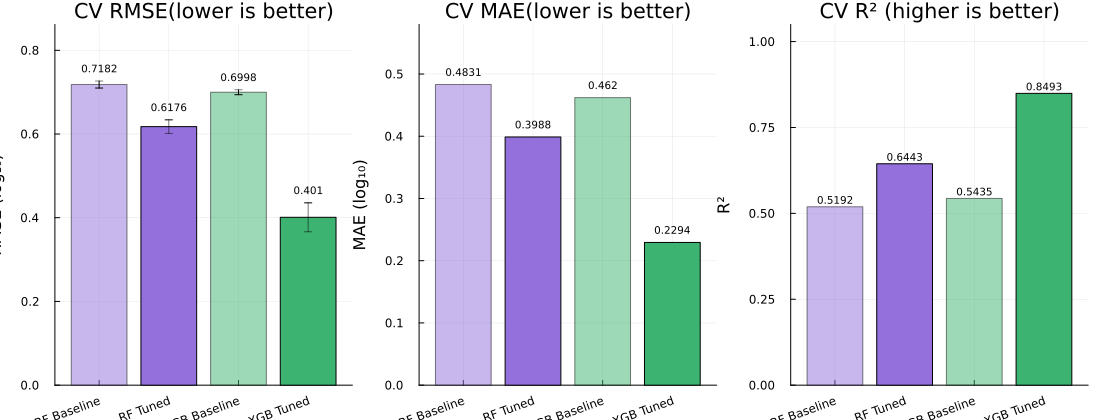

In [60]:
function plot_model_comparison(results::Vector{ModelResult})
    labels    = [r.label for r in results]
    rmse_vals = [r.rmse  for r in results]
    rmse_stds = [r.rmse_std for r in results]
    mae_vals  = [r.mae   for r in results]
    r2_vals   = [r.r2    for r in results]

    # color by model family
    colors = [occursin("RF", r.label) ? :mediumpurple : :mediumseagreen for r in results]
    alphas = [occursin("Baseline", r.label) ? 0.5 : 1.0 for r in results]

    p1 = bar(labels, rmse_vals,
        yerror    = rmse_stds,
        title     = "CV RMSE(lower is better)",
        ylabel    = "RMSE (log₁₀)",
        label     = false,
        color     = colors,
        alpha     = alphas,
        xrotation = 20,
        ylims     = (0, maximum(rmse_vals) * 1.2)
    )
    annotate!(p1, [(i-0.5, rmse_vals[i] + rmse_stds[i] + 0.03,
        text(round(rmse_vals[i], digits=4), 7, :center)) for i in 1:length(results)])

    p2 = bar(labels, mae_vals,
        title     = "CV MAE(lower is better)",
        ylabel    = "MAE (log₁₀)",
        label     = false,
        color     = colors,
        alpha     = alphas,
        xrotation = 20,
        ylims     = (0, maximum(mae_vals) * 1.2)
    )
    annotate!(p2, [(i-0.5, mae_vals[i] + 0.02,
        text(round(mae_vals[i], digits=4), 7, :center)) for i in 1:length(results)])

    p3 = bar(labels, r2_vals,
        title     = "CV R² (higher is better)",
        ylabel    = "R²",
        label     = false,
        color     = colors,
        alpha     = alphas,
        xrotation = 20,
        ylims     = (0, 1.05)
    )
        annotate!(p3, [(i-0.5, r2_vals[i] + 0.02,
        text(round(r2_vals[i], digits=4), 7, :center)) for i in 1:length(results)])

    plot(p1, p2, p3, layout=(1, 3), size=(1100, 420))
end
# plot baseline vs tuned for both models
plot_model_comparison([rf_baseline_result, rf_tuned_result, xgb_baseline_result, xgb_tuned_result])

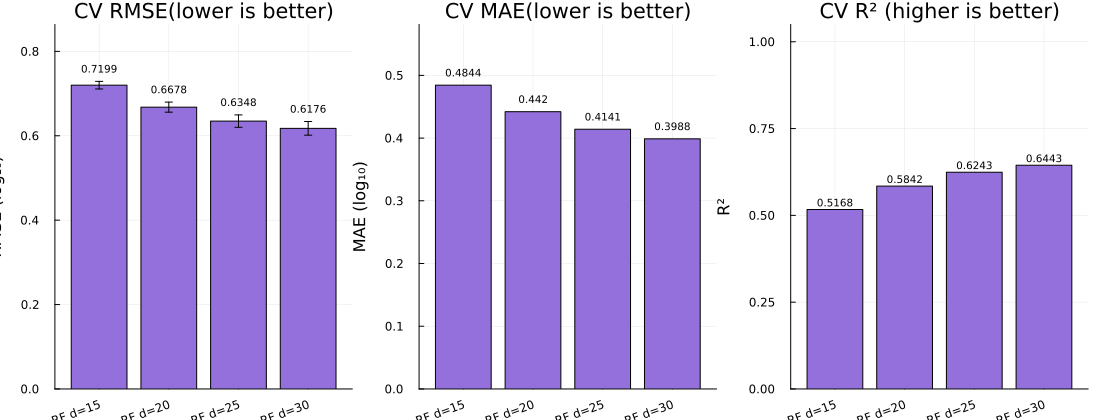

In [61]:
plot_model_comparison(rf_cv_results)

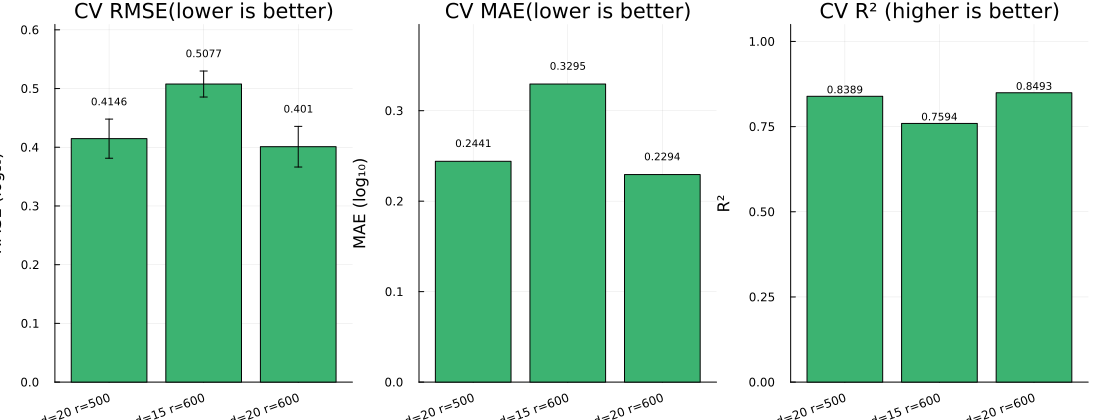

In [62]:
plot_model_comparison(xgb_cv_results)

## Phase 3 - Feature Selection on Winning Model

In [63]:
# determine winner from phase 2
winner_type   = rf_tuned_result.rmse <= xgb_tuned_result.rmse ? :rf : :xgb
winner_model  = winner_type == :rf ? rf_model : xgb_model
winner_tuned  = winner_type == :rf ? rf_tuned_result : xgb_tuned_result
winner_params_rf  = winner_type == :rf ? rf_best_params : nothing
winner_params_xgb = winner_type == :xgb ? xgb_best_params : nothing

println("Phase 2 winner: $(winner_tuned.label)")



Phase 2 winner: XGB Tuned


In [64]:
# validation slice from train for permutation importance
val_cut = round(Int, size(X_train, 1) * 0.8);
X_val   = X_train[val_cut+1:end, :];
y_val   = y_train[val_cut+1:end];

### Permutation importance, Adaptive Threshold, and Elbow Curve

In [77]:
function permutation_importance(model, model_type::Symbol,
                                X::Matrix{Float64}, y::Vector{Float64},
                                feature_cols::Vector;
                                n_repeats::Int=5, seed::Int=42,
                                subsample::Int=50_000)
    Random.seed!(seed)

    # subsample for speed
    n   = length(y)
    idx = n <= subsample ? (1:n) : randperm(n)[1:subsample]
    X   = X[idx, :]
    y   = y[idx]

    # drop near-zero variance features
    active_mask = [std(X[:, j]) > 1e-6 for j in 1:size(X, 2)]
    active_idxs = findall(active_mask)
    println("  Active features: $(length(active_idxs)) / $(length(feature_cols)) (dropped $(sum(.!active_mask)) zero-variance)")

    # baseline
    if model_type == :rf
        baseline_preds = apply_forest(model, X)
    elseif model_type == :xgb
        baseline_preds = XGBoost.predict(model, DMatrix(X))
    end
    baseline_rmse = sqrt(mean((y .- baseline_preds) .^ 2))
    println("  Baseline RMSE: $(round(baseline_rmse, digits=4))")
    println("  Running $(length(active_idxs)) features × $n_repeats repeats on $(length(y)) rows...\n")

    importances = zeros(length(feature_cols))
    X_perm      = copy(X)  # one copy, reused across all features

    for j in active_idxs
        original_col = copy(X[:, j])
        fold_rmses   = zeros(n_repeats)

        for r in 1:n_repeats
            X_perm[:, j] = shuffle(original_col)
            if model_type == :rf
                fold_rmses[r] = sqrt(mean((y .- apply_forest(model, X_perm)) .^ 2))
            elseif model_type == :xgb
                fold_rmses[r] = sqrt(mean((y .- XGBoost.predict(model, DMatrix(X_perm))) .^ 2))
            end
        end

        X_perm[:, j]  = original_col
        importances[j] = mean(fold_rmses) - baseline_rmse
        println("  ✓ $(rpad(string(feature_cols[j]), 35)) importance: $(round(importances[j], digits=4))")
    end

    imp_df = DataFrame(
        feature                = string.(feature_cols),
        permutation_importance = importances
    )
    sort!(imp_df, :permutation_importance, rev=true)
    return imp_df
end
function adaptive_threshold(imp_df::DataFrame)
    vals      = imp_df.permutation_importance
    pos_vals  = vals[vals .> 0]
    μ         = mean(pos_vals)
    σ         = std(pos_vals)
    threshold = μ + 0.5σ

    total     = sum(pos_vals)
    imp_df[!, :cumulative_pct] = cumsum(max.(vals, 0) ./ total .* 100)

    println("\n=== Adaptive Threshold (μ + 0.5σ = $(round(threshold, digits=4))) ===")
    println(@sprintf("%-35s %-12s %-12s %s", "FEATURE", "IMPORTANCE", "CUMUL %", ""))
    println("-"^70)
    for row in eachrow(imp_df)
        marker = row.permutation_importance >= threshold ? " ◀ keep" : ""
        @printf("%-35s %-12.4f %-12.1f%%%s\n",
            row.feature, row.permutation_importance, row.cumulative_pct, marker)
    end

    kept = imp_df[imp_df.permutation_importance .>= threshold, :]
    @printf("\nFeatures kept: %d / %d\n", nrow(kept), nrow(imp_df))
    return kept, threshold
end

function optimize_feature_count(X_train::Matrix{Float64}, y_train::Vector{Float64},
                                 folds::Vector, imp_df::DataFrame,
                                 feature_cols::Vector, model_type::Symbol;
                                 seed::Int=42,
                                 # best params from phase 2
                                 rf_params=nothing, xgb_params=nothing)
    with_logger(NullLogger()) do
    sorted_features = imp_df.feature
    max_n           = length(sorted_features)
    results_log     = DataFrame(n_features=Int[], rmse=Float64[], std=Float64[])

    println("\n=== Elbow Curve — Feature Count Optimization ===")

    for n in 1:max_n
        current_cols = [findfirst(==(f), string.(feature_cols)) for f in sorted_features[1:n]]
        rmse_scores  = Float64[]

        for fold in folds
            X_tr = X_train[fold.train, current_cols]
            X_vl = X_train[fold.val,   current_cols]
            y_tr = y_train[fold.train]
            y_vl = y_train[fold.val]

            if model_type == :rf
                p = rf_params
                model = build_forest(y_tr, X_tr,
                    round(Int, sqrt(n)),
                    500, 0.7, p.max_depth; rng=seed)
                preds = apply_forest(model, X_vl)
            elseif model_type == :xgb
                p     = xgb_params
                model = xgboost(DMatrix(X_tr, label=y_tr);
                    num_round=p.num_round, max_depth=p.max_depth,
                    eta=p.eta, subsample=p.subsample,
                    colsample_bytree=0.8,
                    objective="reg:squarederror",
                    seed=seed)
                preds = predict(model, DMatrix(X_vl))
            end

            push!(rmse_scores, sqrt(mean((y_vl .- preds) .^ 2)))
        end

        mean_rmse = mean(rmse_scores)
        std_rmse  = std(rmse_scores)
        push!(results_log, (n, mean_rmse, std_rmse))
        @printf("  Top %2d features | RMSE: %.4f ± %.4f\n", n, mean_rmse, std_rmse)
    end

    best_n   = results_log[argmin(results_log.rmse), :n_features]
    best_rmse = minimum(results_log.rmse)
    println("\n  Optimal feature count: $best_n | RMSE: $(round(best_rmse, digits=4))")

    # elbow plot
    p = plot(results_log.n_features, results_log.rmse,
        ribbon     = results_log.std,
        fillalpha  = 0.2,
        xlabel     = "number of features",
        ylabel     = "CV RMSE (log₁₀)",
        title      = "Elbow Curve — Feature Count vs RMSE",
        label      = "CV RMSE",
        marker     = :circle,
        color      = :steelblue,
        linewidth  = 2,
        size       = (700, 400)
    )
    vline!(p, [best_n],
        label     = "optimal n=$(best_n)",
        color     = :red,
        linestyle = :dash,
        linewidth = 2)
    display(p)

        # at the end of the function before return
    savefig(p, "elbow_curve_$Dates.Day().png")
    display(p)

    return best_n, results_log
    end
end

#imp_df = permutation_importance(xgb_model, :xgb, X_train, y_train, feature_cols)

optimize_feature_count (generic function with 1 method)

In [ ]:

# filter matrices to selected features
selected_idxs = [i for (i, f) in enumerate(feature_cols) if f in Set(kept_features.feature)]
X_train_selected = X_train[:, selected_idxs]
X_test_selected  = X_test[:,  selected_idxs]
feature_cols_selected = feature_cols[selected_idxs]

println("Features reduced: $(length(feature_cols)) → $(length(selected_idxs))")

Permutation importance loaded from CSV.
Adaptive threshold loaded from CSV.

Running elbow curve...

=== Elbow Curve — Feature Count Optimization ===
  Top  1 features | RMSE: 0.8972 ± 0.0075
  Top  2 features | RMSE: 0.8520 ± 0.0076
  Top  3 features | RMSE: 0.7979 ± 0.0084
  Top  4 features | RMSE: 0.7131 ± 0.0127
  Top  5 features | RMSE: 0.6304 ± 0.0194
  Top  6 features | RMSE: 0.5934 ± 0.0263
  Top  7 features | RMSE: 0.5605 ± 0.0301
  Top  8 features | RMSE: 0.5364 ± 0.0327
  Top  9 features | RMSE: 0.5207 ± 0.0330
  Top 10 features | RMSE: 0.5079 ± 0.0372
  Top 11 features | RMSE: 0.5082 ± 0.0351
  Top 12 features | RMSE: 0.4977 ± 0.0362

  Optimal feature count: 12 | RMSE: 0.4977


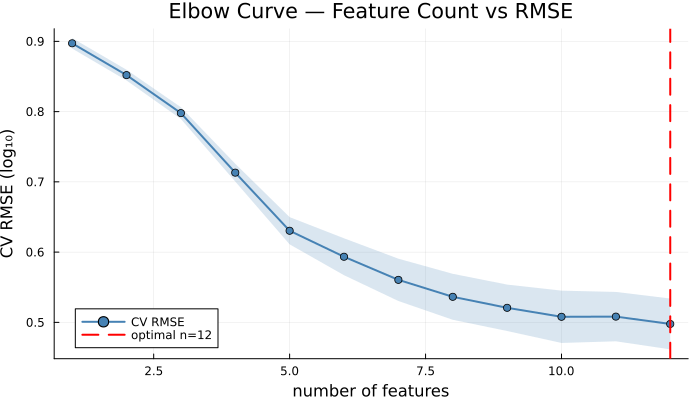

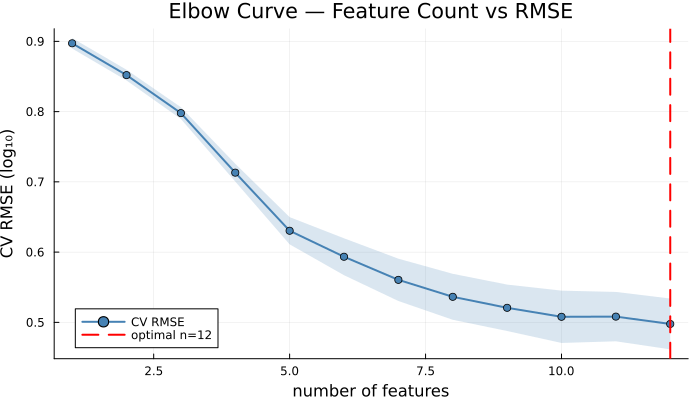

"/Users/paola/Docs/dev/phantom_project/project 1 - estimating potential total value/elbow_curve_2026-05-07_18-07-15.png"

In [ ]:
RUN_PERMUTATION_IMPORTANCE = false
perm_imp_path = "xgb_permutation_importance_2026-05-07_17-06-05.csv"

RUN_ADAPTIVE_THRESHOLD     = false
adaptive_threshold_path = "adaptive_threshold_results_2026-05-07_17-30-18.csv"

RUN_ELBOW_CURVE            = true
#elbow_curve_path = "elbow_curve_results_2026-05-07_17-11-45.csv"

if RUN_PERMUTATION_IMPORTANCE
    println("\nRunning permutation importance...")
    imp_df = permutation_importance(winner_model, winner_type, X_val, y_val, feature_cols)
    CSV.write("permutation_importance_results_$(Dates.format(now(), "yyyy-mm-dd_HH-MM-SS")).csv", imp_df)
    # step 1 — permutation importance
else
    imp_df = CSV.read(perm_imp_path, DataFrame)
    println("Permutation importance loaded from CSV.")
end

if RUN_ADAPTIVE_THRESHOLD
    println("\nRunning adaptive threshold...")
    kept_features, threshold = adaptive_threshold(imp_df)
    CSV.write("adaptive_threshold_results_$(Dates.format(now(), "yyyy-mm-dd_HH-MM-SS")).csv", kept_features)
else
    kept_features = CSV.read(adaptive_threshold_path, DataFrame)
    threshold = mean(kept_features.permutation_importance) # or hardcode it
    println("Adaptive threshold loaded from CSV.")
end

if RUN_ELBOW_CURVE
    println("\nRunning elbow curve...")
    best_n, elbow_results = optimize_feature_count(
        X_train, y_train, folds, kept_features, feature_cols, winner_type;
        rf_params=winner_params_rf, xgb_params=winner_params_xgb, seed=42)
        #save results with todays date and time
    CSV.write("elbow_curve_results_$(Dates.format(now(), "yyyy-mm-dd_HH-MM-SS")).csv", elbow_results)
    savefig("elbow_curve_$(Dates.format(now(), "yyyy-mm-dd_HH-MM-SS")).png")
elseif CONTINUE_FROM_SAVED_ELBOW
    # if my elbow curve analysis was interrupted
    # continue doing elbow curve with more features 
    # starting from the latest n in the saved results
    
best_n, elbow_results = optimize_feature_count(
        X_train, y_train, folds, imp_df, feature_cols, winner_type;
        rf_params=winner_params_rf, xgb_params=winner_params_xgb, seed=42)
        #save results with todays date and time
else
    elbow_results = CSV.read(elbow_curve_path, DataFrame)
    best_n        = elbow_results[argmin(elbow_results.rmse), :n_features]
    println("Elbow curve loaded from CSV. Best n=$best_n")

    # rebuild plot from saved results
    plt = plot(elbow_results.n_features, elbow_results.rmse,
        ribbon    = elbow_results.std,
        fillalpha = 0.2,
        xlabel    = "number of features",
        ylabel    = "CV RMSE (log₁₀)",
        title     = "Feature Count vs RMSE",
        label     = "CV RMSE",
        marker    = :circle,
        color     = :mediumseagreen,
        linewidth = 2,
        size      = (700, 400)
    )
    vline!(plt, [best_n],
        label     = "optimal n=$(best_n)",
        color     = :deeppink,
        linestyle = :dash,
        linewidth = 2)
    display(plt)
end

### Refit winning model with pruned features


=== Phase 3 Summary ===
  XGB Tuned                           RMSE: 0.4010 ± 0.0346 | R²: 0.8493
  XGB Pruned (top 12)                 RMSE: 0.4977 ± 0.0362 | R²: 0.7681

  ✓ Full-feature model wins — keeping all features.


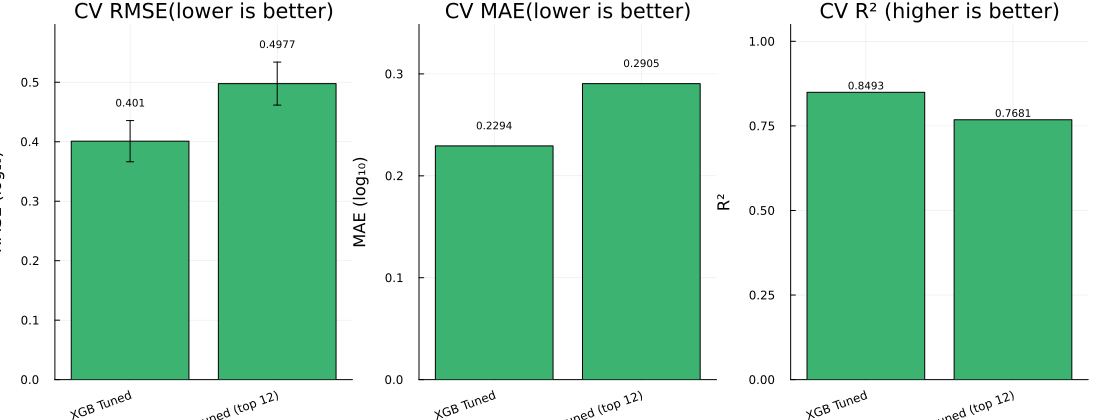

In [93]:
# ============================================================
# PHASE 3 — FEATURE SELECTION + FINAL MODEL
# ============================================================

# --- Step 1: CV score the pruned model ---
function cv_score_pruned(X_train, y_train, folds, imp_df, best_n,
                         feature_cols, model_type;
                         rf_params=nothing, xgb_params=nothing, seed=42)
    with_logger(NullLogger()) do
        top_features = imp_df.feature[1:best_n]
        col_idx      = [findfirst(==(f), string.(feature_cols)) for f in top_features]
        X_pruned     = X_train[:, col_idx]

        rmse_scores, mae_scores, r2_scores = Float64[], Float64[], Float64[]

        for fold in folds
            X_tr = X_pruned[fold.train, :]
            X_vl = X_pruned[fold.val,   :]
            y_tr = y_train[fold.train]
            y_vl = y_train[fold.val]

            if model_type == :rf
                model = build_forest(y_tr, X_tr,
                    round(Int, sqrt(best_n)),
                    500, 0.7, rf_params.max_depth; rng=seed)
                preds = apply_forest(model, X_vl)
            elseif model_type == :xgb
                model = xgboost(DMatrix(X_tr, label=y_tr);
                    num_round=xgb_params.num_round, max_depth=xgb_params.max_depth,
                    eta=xgb_params.eta, subsample=xgb_params.subsample,
                    colsample_bytree=0.8, objective="reg:squarederror", seed=seed)
                preds = XGBoost.predict(model, DMatrix(X_vl))
            end

            rmse, mae, r2 = score_predictions(y_vl, preds)
            push!(rmse_scores, rmse)
            push!(mae_scores,  mae)
            push!(r2_scores,   r2)
        end

        prefix = model_type == :rf ? "RF" : "XGB"
        pruned_result = ModelResult("$(prefix) Pruned (top $(best_n))",
            mean(rmse_scores), std(rmse_scores),
            mean(mae_scores),  std(mae_scores),
            mean(r2_scores),   std(r2_scores))

        return pruned_result, col_idx
    end
end


# --- Step 2: refit winner on full training data ---
function refit_final(X_train, y_train, col_idx, model_type;
                     rf_params=nothing, xgb_params=nothing, seed=42)
    with_logger(NullLogger()) do
        X_sub = X_train[:, col_idx]
        n     = length(col_idx)

        if model_type == :rf
            return build_forest(y_train, X_sub,
                round(Int, sqrt(n)), 500, 0.7, rf_params.max_depth; rng=seed)
        elseif model_type == :xgb
            return xgboost(DMatrix(X_sub, label=y_train);
                num_round=xgb_params.num_round, max_depth=xgb_params.max_depth,
                eta=xgb_params.eta, subsample=xgb_params.subsample,
                colsample_bytree=0.8, objective="reg:squarederror",
                seed=seed, verbosity=0)
        end
    end
end


# --- Step 3: compare and pick winner ---
function select_final_model(winner_model, winner_tuned, pruned_model, pruned_result,
                            full_col_idx, pruned_col_idx)
    @printf("\n=== Phase 3 Summary ===\n")
    @printf("  %-35s RMSE: %.4f ± %.4f | R²: %.4f\n",
        winner_tuned.label, winner_tuned.rmse, winner_tuned.rmse_std, winner_tuned.r2)
    @printf("  %-35s RMSE: %.4f ± %.4f | R²: %.4f\n",
        pruned_result.label, pruned_result.rmse, pruned_result.rmse_std, pruned_result.r2)

    if pruned_result.rmse <= winner_tuned.rmse
        println("\n  ✓ Pruned model wins — using top $(length(pruned_col_idx)) features.")
        return pruned_model, pruned_col_idx, pruned_result
    else
        println("\n  ✓ Full-feature model wins — keeping all features.")
        return winner_model, full_col_idx, winner_tuned
    end
end


# ============================================================
# RUN PHASE 3
# ============================================================

# step 1 — CV score pruned
pruned_result, pruned_col_idx = cv_score_pruned(
    X_train, y_train, folds, imp_df, best_n,
    feature_cols, winner_type;
    rf_params=winner_params_rf, xgb_params=winner_params_xgb)

# step 2 — refit pruned on full training data
pruned_model = refit_final(
    X_train, y_train, pruned_col_idx, winner_type;
    rf_params=winner_params_rf, xgb_params=winner_params_xgb)

# step 3 — compare + select
full_col_idx = collect(1:length(feature_cols))

final_model, final_col_idx, final_result = select_final_model(
    winner_model, winner_tuned,
    pruned_model, pruned_result,
    full_col_idx, pruned_col_idx)

# step 4 — plot
plot_model_comparison([winner_tuned, pruned_result])

In [ ]:
# function refit_pruned_model(X_train::Matrix{Float64}, y_train::Vector{Float64},
#                              folds::Vector, feature_cols::Vector,
#                              imp_df::DataFrame, best_n::Int,
#                              model_type::Symbol, phase2_result::ModelResult;
#                              rf_params=nothing, xgb_params=nothing,
#                              seed::Int=42)
#     with_logger(NullLogger()) do
#     top_features  = imp_df.feature[1:best_n]
#     col_idx       = [findfirst(==(f), string.(feature_cols)) for f in top_features]
#     X_pruned      = X_train[:, col_idx]

#     rmse_scores, mae_scores, r2_scores = Float64[], Float64[], Float64[]

#     for fold in folds
#         X_tr = X_pruned[fold.train, :]
#         X_vl = X_pruned[fold.val,   :]
#         y_tr = y_train[fold.train]
#         y_vl = y_train[fold.val]

#         if model_type == :rf
#             model = build_forest(y_tr, X_tr,
#                 round(Int, sqrt(best_n)),
#                 500, 0.7, rf_params.max_depth; rng=seed)
#             preds = apply_forest(model, X_vl)
#         elseif model_type == :xgb
#             model = xgboost(DMatrix(X_tr, label=y_tr);
#                 num_round=xgb_params.num_round, max_depth=xgb_params.max_depth,
#                 eta=xgb_params.eta, subsample=xgb_params.subsample,
#                 colsample_bytree=0.8, objective="reg:squarederror",
#                 seed=seed)
#             preds = predict(model, DMatrix(X_vl))
#         end

#         rmse, mae, r2 = score_predictions(y_vl, preds)
#         push!(rmse_scores, rmse)
#         push!(mae_scores,  mae)
#         push!(r2_scores,   r2)
#     end

#     prefix = model_type == :rf ? "RF" : "XGB"
#     pruned_result = ModelResult("$(prefix) Pruned (top $(best_n))",
#         mean(rmse_scores), std(rmse_scores),
#         mean(mae_scores),  std(mae_scores),
#         mean(r2_scores),   std(r2_scores))

#     @printf("\n=== Phase 3 Summary ===\n")
#     @printf("  %-30s RMSE: %.4f ± %.4f | R²: %.4f\n",
#         phase2_result.label, phase2_result.rmse, phase2_result.rmse_std, phase2_result.r2)
#     @printf("  %-30s RMSE: %.4f ± %.4f | R²: %.4f\n",
#         pruned_result.label, pruned_result.rmse, pruned_result.rmse_std, pruned_result.r2)

#     # refit final pruned model on all training data
#     println("\n  Refitting pruned model on full training set...")
#     if model_type == :rf
#         final_model = build_forest(y_train, X_pruned,
#             round(Int, sqrt(best_n)), 500, 0.7, rf_params.max_depth; rng=seed)
#     elseif model_type == :xgb
#         final_model = xgboost(DMatrix(X_pruned, label=y_train);
#             num_round=xgb_params.num_round, max_depth=xgb_params.max_depth,
#             eta=xgb_params.eta, subsample=xgb_params.subsample,
#             colsample_bytree=0.8, objective="reg:squarederror",
#             seed=seed, verbosity=0)
#     end

#     return final_model, col_idx, pruned_result
#     end
# end

# # step 4 — refit pruned model + CV score
# final_model, final_col_idx, pruned_result = refit_pruned_model(
#     X_train, y_train, folds, feature_cols, imp_df, best_n,
#     winner_type, winner_tuned;
#     rf_params=winner_params_rf, xgb_params=winner_params_xgb)

InterruptException: InterruptException:

### Compare Pruned vs Full Feature model 

In [ ]:
# step 5 — plot phase 3 comparison
# p = plot_model_comparison([winner_tuned, pruned_result])
savefig(p, "compare_tuned_vs_pruned_05-07-2026.png")

"/Users/paola/Docs/dev/phantom_project/project 1 - estimating potential total value/compare_tuned_vs_pruned_05-07-2026.png"

## Phase 4 - Final Evaluation

1. Take single best model from Phase 3
2. Evaluate it ONCE on Xtest
3. Report test RMSE, MAE, R^2
4. Back-transform to predicted dollars = 10.^predictions

In [94]:
# ============================================================
# PHASE 4 — FINAL EVALUATION
# ============================================================

function evaluate_final_model(model, model_type::Symbol,
                               X_test::Matrix{Float64}, y_test::Vector{Float64},
                               feature_cols::Vector, col_idx::Vector{Int})

    # subset test set to pruned features
    X_test_pruned = X_test[:, col_idx]

    # predict on log scale
    if model_type == :rf
        log_preds = apply_forest(model, X_test_pruned)
    elseif model_type == :xgb
        log_preds = XGBoost.predict(model, DMatrix(X_test_pruned))
    end

    # metrics on log scale
    rmse, mae, r2 = score_predictions(y_test, log_preds)

    # back-transform to dollars
    pred_dollars = 10 .^ log_preds
    true_dollars = 10 .^ y_test

    # dollar-scale metrics
    dollar_residuals  = true_dollars .- pred_dollars
    dollar_rmse       = sqrt(mean(dollar_residuals .^ 2))
    dollar_mae        = mean(abs.(dollar_residuals))
    dollar_ss_res     = sum(dollar_residuals .^ 2)
    dollar_ss_tot     = sum((true_dollars .- mean(true_dollars)) .^ 2)
    dollar_r2         = 1 - dollar_ss_res / dollar_ss_tot

    # median absolute percentage error — more interpretable than RMSE for log-normal
    mape = median(abs.(dollar_residuals ./ true_dollars) .* 100)

    println("=== PHASE 4 — FINAL TEST SET EVALUATION ===")
    println("\n  Log₁₀ Scale (what the model optimized):")
    @printf("    RMSE: %.4f\n", rmse)
    @printf("    MAE:  %.4f\n", mae)
    @printf("    R²:   %.4f\n", r2)

    println("\n  Dollar Scale (back-transformed):")
    @printf("    RMSE:   \$%.2f\n",   dollar_rmse)
    @printf("    MAE:    \$%.2f\n",   dollar_mae)
    @printf("    R²:     %.4f\n",     dollar_r2)
    @printf("    MdAPE:  %.1f%%\n",   mape)

    println("\n  Interpretation:")
    @printf("    Median prediction is within %.1f%% of true value\n", mape)
    @printf("    A log RMSE of %.4f means ~%.1fx typical error in dollar terms\n",
        rmse, 10^rmse)

    # results dataframe for further analysis
    results_df = DataFrame(
        true_log       = y_test,
        pred_log       = log_preds,
        true_dollars   = true_dollars,
        pred_dollars   = pred_dollars,
        abs_pct_error  = abs.(dollar_residuals ./ true_dollars) .* 100,
        log_residual   = y_test .- log_preds
    )

    return results_df, (
        log_rmse     = rmse,
        log_mae      = mae,
        log_r2       = r2,
        dollar_rmse  = dollar_rmse,
        dollar_mae   = dollar_mae,
        dollar_r2    = dollar_r2,
        mape         = mape
    )
end


function plot_final_results(results_df::DataFrame, test_metrics)

    # 1 — predicted vs actual (log scale)
    p1 = scatter(results_df.true_log, results_df.pred_log,
        xlabel    = "actual log₁₀(award amount)",
        ylabel    = "predicted log₁₀(award amount)",
        title     = "Predicted vs Actual",
        label     = false,
        alpha     = 0.3,
        markersize = 2,
        color     = :steelblue,
        size      = (500, 450)
    )
    # perfect prediction line
    min_val = minimum(results_df.true_log)
    max_val = maximum(results_df.true_log)
    plot!(p1, [min_val, max_val], [min_val, max_val],
        label     = "perfect fit",
        color     = :red,
        linestyle = :dash,
        linewidth = 2)

    # 2 — residuals vs predicted (log scale)
    p2 = scatter(results_df.pred_log, results_df.log_residual,
        xlabel    = "predicted log₁₀(award amount)",
        ylabel    = "residual",
        title     = "Residuals vs Predicted",
        label     = false,
        alpha     = 0.3,
        markersize = 2,
        color     = :steelblue,
        size      = (500, 450)
    )
    hline!(p2, [0.0],
        color     = :red,
        linestyle = :dash,
        linewidth = 2,
        label     = "zero")

    # 3 — residual distribution
    p3 = histogram(results_df.log_residual,
        normalize  = :pdf,
        bins       = 60,
        xlabel     = "residual (log₁₀ scale)",
        ylabel     = "density",
        title      = "Residual Distribution",
        label      = false,
        color      = :steelblue,
        alpha      = 0.7,
        size       = (500, 450)
    )
    vline!(p3, [0.0],
        color     = :red,
        linestyle = :dash,
        linewidth = 2,
        label     = "zero")

    # 4 — absolute % error distribution (capped at 200% for readability)
    capped_errors = min.(results_df.abs_pct_error, 200.0)
    p4 = histogram(capped_errors,
        normalize  = :pdf,
        bins       = 50,
        xlabel     = "absolute % error (capped at 200%)",
        ylabel     = "density",
        title      = "% Error Distribution",
        label      = false,
        color      = :coral,
        alpha      = 0.7,
        size       = (500, 450)
    )
    vline!(p4, [test_metrics.mape],
        color     = :red,
        linestyle = :dash,
        linewidth = 2,
        label     = "median $(round(test_metrics.mape, digits=1))%")

    plot(p1, p2, p3, p4,
        layout = (2, 2),
        size   = (1000, 850),
        plot_title = "Final Model Evaluation — Test Set"
    )
end


# ============================================================
# RUN PHASE 4
# ============================================================

results_df, test_metrics = evaluate_final_model(
    final_model, winner_type,
    X_test, y_test,
    feature_cols, final_col_idx
)


=== PHASE 4 — FINAL TEST SET EVALUATION ===

  Log₁₀ Scale (what the model optimized):
    RMSE: 0.6440
    MAE:  0.4004
    R²:   0.6109

  Dollar Scale (back-transformed):
    RMSE:   $61226386.80
    MAE:    $1907595.48
    R²:     0.1666
    MdAPE:  57.7%

  Interpretation:
    Median prediction is within 57.7% of true value
    A log RMSE of 0.6440 means ~4.4x typical error in dollar terms


(86688×6 DataFrame
   Row │ true_log  pred_log  true_dollars    pred_dollars   abs_pct_error  log ⋯
       │ Float64   Float32   Float64         Float32        Float64        Flo ⋯
───────┼────────────────────────────────────────────────────────────────────────
     1 │  7.27351   6.7563        1.87718e7      5.70554e6       69.6059       ⋯
     2 │  6.10485   6.0729        1.27305e6      1.18277e6        7.09184
     3 │  6.85338   6.88534       7.13478e6      7.67956e6        7.63556    -
     4 │  3.73325   3.7074     5410.6         5098.01             5.77744
     5 │  5.49467   5.61117       3.12368e5      4.08482e5       30.7696     - ⋯
     6 │  4.44497   4.56378   27859.4        36625.5             31.4652     -
     7 │  5.52194   4.72563  332611.0        53165.0             84.0159
     8 │  5.54198   5.06965       3.48324e5      1.17394e5       66.2975
   ⋮   │    ⋮         ⋮            ⋮               ⋮              ⋮            ⋱
 86682 │  5.0547    5.21454       1.13424e5

In [97]:
p = plot_final_results(results_df, test_metrics)
savefig(p, "final_evaluation_plots_using_full_model_05-07-2026-1905.png")

"/Users/paola/Docs/dev/phantom_project/project 1 - estimating potential total value/final_evaluation_plots_using_full_model_05-07-2026-1905.png"